# 01 — What a porosity field is, and how to infer its Gaussian process

**Series:** field-controlled generation in 2D · notebook 1 of 5

This notebook is the conceptual foundation of the whole method. It answers three
questions, in order:

1. **What is a porosity field?** — a local average of the pore indicator. One number
   per position, saying "how porous is the rock *around here*".
2. **Why is it nearly Gaussian after a logit transform?** — because a local average over
   a window much larger than the pore correlation length is a sum of nearly independent
   contributions, and the logit maps $(0,1)$ to $\mathbb{R}$.
3. **How do we fit a generative model for it?** — estimate mean, variance, and a Matérn
   correlation length from the two-point covariance, then sample new fields from that
   Gaussian process.

Everything here is the 2D mirror of `pipelines/fieldcontrolled/0002-porosity-field-estimator.py`.
The artifacts written at the end (`berea_slices.npy`, `berea_field_w129.npy`,
`berea_gp_w129_latent.npz`) are exactly the inputs that notebooks 02–05 consume, in the
same way that `0002` produces the `*_porosity_field_full.npy` and `*_porosity_analysis.npz`
that `0003` and `0004e` consume.

---

### Why this matters at all

A diffusion model trained on $256^2$ patches learns the distribution of $256^2$ patches.
It does **not** learn the distribution of $1024^2$ images. Asking it for a large image is
asking a question the training data cannot answer — the problem is genuinely ill-posed.

Field controlling makes the missing assumption *explicit*. We factor the large-scale
distribution as

$$\mu(A) \;=\; \int \mu(A \mid \phi)\, d\mu_\phi(\phi),$$

sample a **porosity field** $\phi$ first, then generate microstructure conditioned on it.
The conditional $\mu(\cdot\mid\phi)$ can be learned from patches (notebook 03); the field
distribution $\mu_\phi$ is what we build here.

---
## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import time

import numpy as np
import scipy.signal
import scipy.special
import scipy.stats
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from diffsci2.extra import two_point_correlation, matern_gaussian_process
from diffsci2.extra.matern_gaussian_process import MaternFieldSampler

import fcconfig as fc

fc.ensure_dirs()
np.random.seed(0)

print(f"window w   = {fc.WINDOW}   -> radius R = {fc.RADIUS}")
print(f"compression F = {fc.F}     -> the field is fitted on the latent grid")

window w   = 129   -> radius R = 64
compression F = 8     -> the field is fitted on the latent grid


In [3]:
volume = np.fromfile(fc.RAW_PATH, dtype=np.uint8).reshape(fc.VOLUME_SHAPE)
print(f"volume   : {volume.shape}  (solid = 1, pore = 0)")
print(f"porosity : {fc.porosity_of(volume):.4f}")

demo_slice = volume[500].astype(np.float32)   # one 1000x1000 slice we will keep reusing
print(f"demo slice porosity: {fc.porosity_of(demo_slice):.4f}")

volume   : (1000, 1000, 1000)  (solid = 1, pore = 0)


porosity : 0.2167
demo slice porosity: 0.2016


---
## 2. The porosity field

For a binary configuration $\omega$ (solid = 1), the **$l$-sized porosity field** is the
local average of the pore indicator over a window $B_l$ centred at $\mathbf{x}$:

$$\phi^\omega(\mathbf{x}) \;=\; \frac{1}{|B_l|}\sum_{\mathbf{y}\in B_l} \bigl(1 - \omega(\mathbf{x}+\mathbf{y})\bigr).$$

That is a convolution, so we compute it with an FFT. There are two versions, and the
distinction matters downstream:

- **`valid`** — only positions where the whole window fits inside the image. Every value
  is a genuine average over $w^2$ real voxels. Shape shrinks by $2R$. *This is what we fit
  the GP to.*
- **`same`** — same shape as the input, with each position divided by the number of
  voxels that actually contributed. Near the border the average is taken over fewer
  voxels, so it is noisier. *This is what we store for training*, because the training
  code needs the field aligned voxel-for-voxel with the binary image; the noisy border is
  then removed by an inward crop of $R$.

In [4]:
def porosity_field_valid(binary, window):
    '''Local pore fraction, 'valid' convolution. Shape shrinks by (window - 1).'''
    kernel = np.ones((window, window), dtype=np.float32) / window ** 2
    pore = 1.0 - binary.astype(np.float32)
    return scipy.signal.fftconvolve(pore, kernel, mode='valid')


def porosity_field_full(binary, window):
    '''Local pore fraction, 'same' convolution with boundary-count normalisation.

    Mirrors calculate_porosity_field_full() in 0002-porosity-field-estimator.py:
    convolve the pore indicator with an *unnormalised* box, convolve a field of ones
    with the same box to count contributors, then divide.
    '''
    kernel = np.ones((window, window), dtype=np.float32)
    pore = 1.0 - binary.astype(np.float32)
    numerator = scipy.signal.fftconvolve(pore, kernel, mode='same')
    # The 2D count factorises into a product of two 1D counts.
    count_h = scipy.signal.fftconvolve(np.ones(binary.shape[0]), np.ones(window), mode='same')
    count_w = scipy.signal.fftconvolve(np.ones(binary.shape[1]), np.ones(window), mode='same')
    return numerator / (count_h[:, None] * count_w[None, :])


phi_valid = porosity_field_valid(demo_slice, fc.WINDOW)
phi_full = porosity_field_full(demo_slice, fc.WINDOW)

print(f"binary       {demo_slice.shape}")
print(f"phi 'valid'  {phi_valid.shape}   range [{phi_valid.min():.3f}, {phi_valid.max():.3f}]")
print(f"phi 'same'   {phi_full.shape}  range [{phi_full.min():.3f}, {phi_full.max():.3f}]")
print(f"mean of phi  {phi_valid.mean():.4f}  vs. slice porosity {fc.porosity_of(demo_slice):.4f}")

binary       (1000, 1000)
phi 'valid'  (872, 872)   range [0.052, 0.356]
phi 'same'   (1000, 1000)  range [0.032, 0.356]
mean of phi  0.2034  vs. slice porosity 0.2016


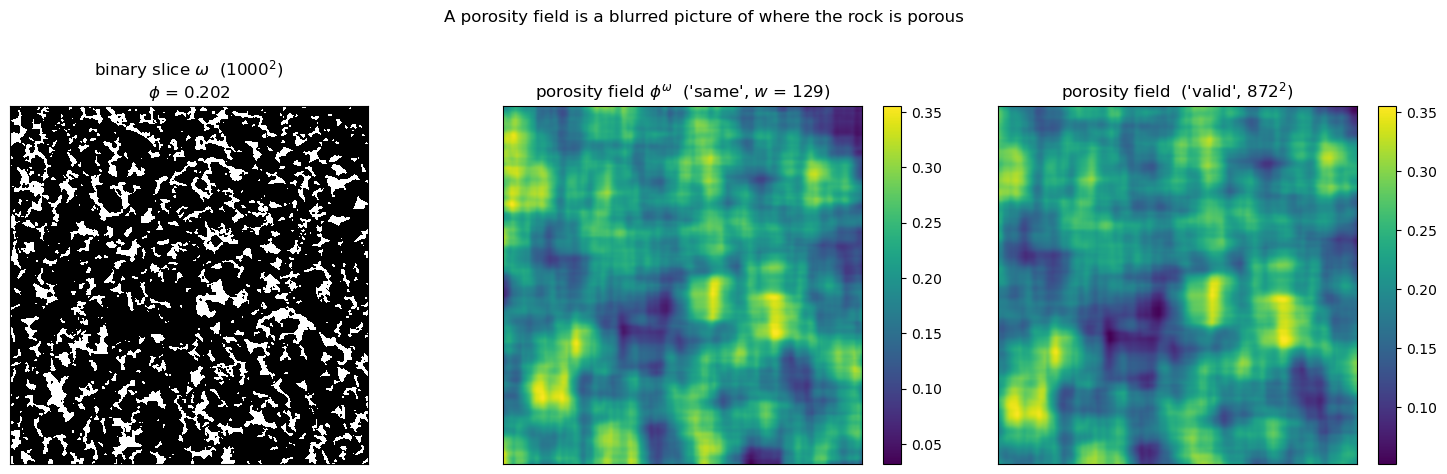

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

axes[0].imshow(demo_slice, cmap='gray_r', interpolation='nearest')
axes[0].set_title(f"binary slice $\\omega$  (1000$^2$)\n$\\phi$ = {fc.porosity_of(demo_slice):.3f}")

im = axes[1].imshow(phi_full, cmap='viridis')
axes[1].set_title(f"porosity field $\\phi^\\omega$  ('same', $w$ = {fc.WINDOW})")
fig.colorbar(im, ax=axes[1], fraction=0.046)

im = axes[2].imshow(phi_valid, cmap='viridis')
axes[2].set_title(f"porosity field  ('valid', {phi_valid.shape[0]}$^2$)")
fig.colorbar(im, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("A porosity field is a blurred picture of where the rock is porous", y=1.02)
fig.tight_layout()
fc.savefig(fig, "01_what_is_a_porosity_field")
plt.show()

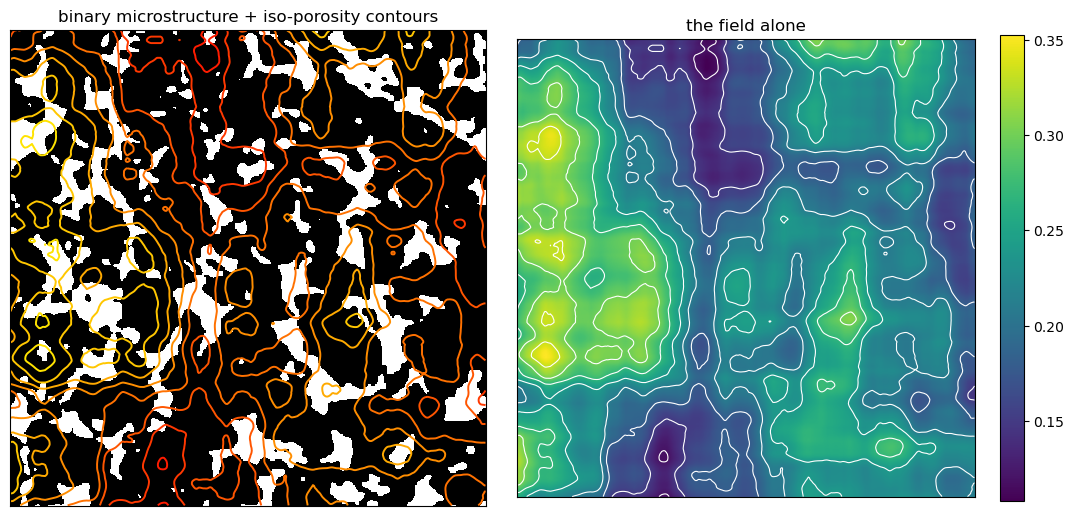

In [6]:
# Overlay: the field is a *coarse-grained* view of the same object.
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
sub = demo_slice[:400, :400]
sub_phi = phi_full[:400, :400]

axes[0].imshow(sub, cmap='gray_r', interpolation='nearest')
axes[0].contour(sub_phi, levels=8, cmap='autumn', linewidths=1.4)
axes[0].set_title("binary microstructure + iso-porosity contours")

im = axes[1].imshow(sub_phi, cmap='viridis')
axes[1].contour(sub_phi, levels=8, colors='w', linewidths=0.8)
axes[1].set_title("the field alone")
fig.colorbar(im, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
fc.savefig(fig, "01_field_overlay")
plt.show()

---
## 3. The window size $w$ is a modelling choice, not a detail

The thesis compares two coarse-graining scales, **FC-129** and **FC-257**, and finds
FC-129 the better of the two: a smaller window keeps more spatial detail in the
conditioning signal, so the generated field tracks the real two-point structure more
closely.

Here is why, visually. Small $w$ gives a field that is detailed but noisy (and less
Gaussian); large $w$ gives a field that is smooth and reliably Gaussian but carries
little information about *where* the rock varies.

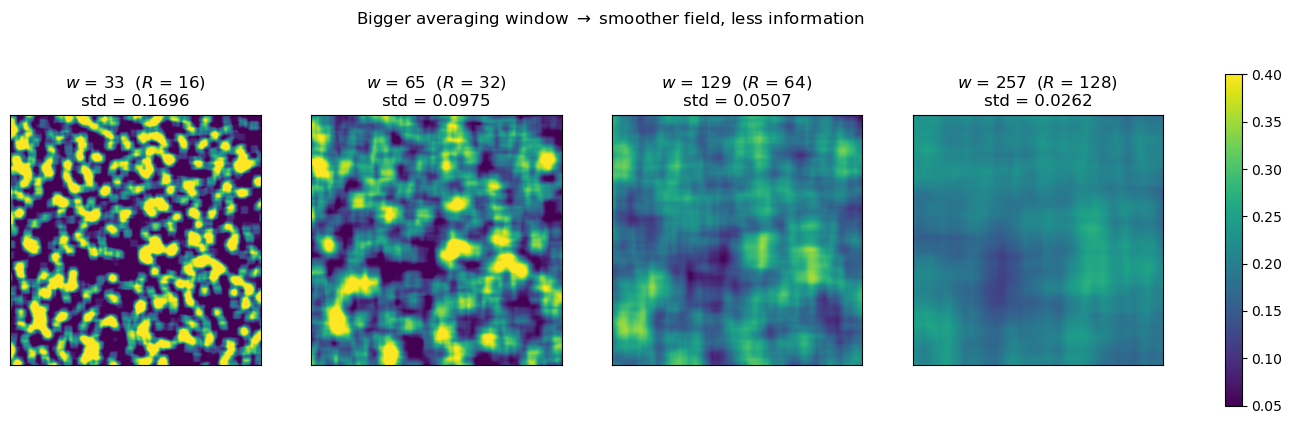

In [7]:
windows = [33, 65, 129, 257]
fields_by_w = {w: porosity_field_valid(demo_slice, w) for w in windows}

fig, axes = plt.subplots(1, len(windows), figsize=(4.0 * len(windows), 4.3))
for ax, w in zip(axes, windows):
    f_w = fields_by_w[w]
    im = ax.imshow(f_w, cmap='viridis', vmin=0.05, vmax=0.40)
    ax.set_title(f"$w$ = {w}  ($R$ = {(w - 1) // 2})\nstd = {f_w.std():.4f}")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, fraction=0.02)
fig.suptitle("Bigger averaging window $\\to$ smoother field, less information", y=1.03)
fc.savefig(fig, "01_window_size_comparison")
plt.show()

---
## 4. Why a *Gaussian* process — and why the logit first

Two separate claims, often conflated:

**(a) The field is approximately Gaussian.** If the binary configuration has a finite
correlation length $\ell$, then voxels more than $\ell$ apart are nearly independent. An
average over a $w^2$ window with $w \gg \ell$ is therefore a sum over roughly $(w/\ell)^2$
nearly-independent blocks, and a central limit theorem for mixing random fields applies.
The approximation gets better as $w/\ell$ grows — which we can just *check*.

**(b) But $\phi \in (0,1)$, and a Gaussian is not.** So we model the **warped** field
$\operatorname{logit}\circ\phi = \log\frac{\phi}{1-\phi}$, which lives on all of
$\mathbb{R}$. This is a *warped Gaussian process*. The logit is monotone (so it preserves
the ordering of porosities) and it pushes mass away from the boundaries, where a raw
Gaussian model would happily predict negative porosity.

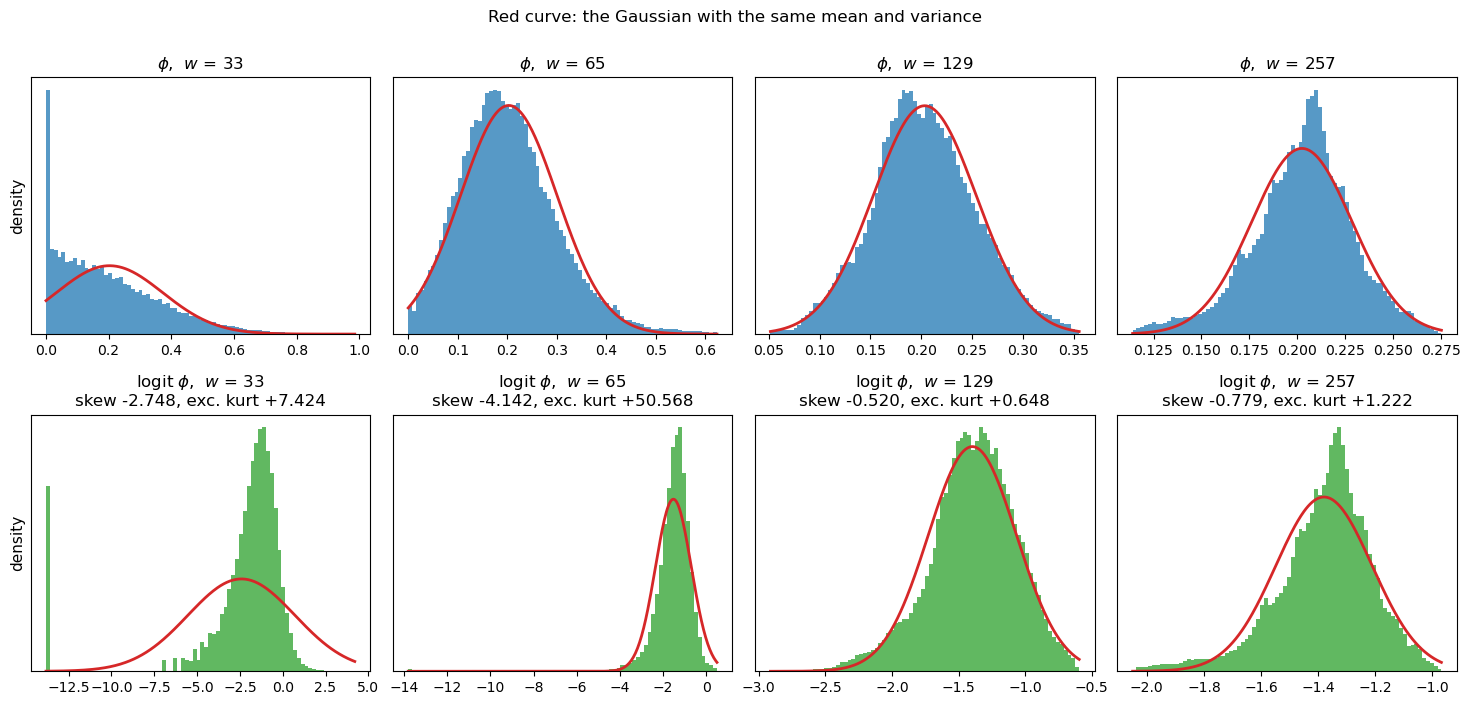

In [8]:
def logit(x, eps=1e-6):
    x = np.clip(x, eps, 1 - eps)
    return np.log(x / (1 - x))


fig, axes = plt.subplots(2, len(windows), figsize=(3.7 * len(windows), 7.0))
for k, w in enumerate(windows):
    f_w = fields_by_w[w].ravel()
    lg_w = logit(f_w)

    # raw phi
    ax = axes[0, k]
    ax.hist(f_w, bins=80, density=True, color='C0', alpha=0.75)
    mu, sd = f_w.mean(), f_w.std()
    xs = np.linspace(f_w.min(), f_w.max(), 300)
    ax.plot(xs, scipy.stats.norm.pdf(xs, mu, sd), 'C3', lw=2)
    ax.set_title(f"$\\phi$,  $w$ = {w}")
    ax.set_yticks([])

    # logit phi, with the normality score
    ax = axes[1, k]
    ax.hist(lg_w, bins=80, density=True, color='C2', alpha=0.75)
    mu, sd = lg_w.mean(), lg_w.std()
    xs = np.linspace(lg_w.min(), lg_w.max(), 300)
    ax.plot(xs, scipy.stats.norm.pdf(xs, mu, sd), 'C3', lw=2)
    skew = scipy.stats.skew(lg_w)
    kurt = scipy.stats.kurtosis(lg_w)
    ax.set_title(f"logit $\\phi$,  $w$ = {w}\nskew {skew:+.3f}, exc. kurt {kurt:+.3f}")
    ax.set_yticks([])

axes[0, 0].set_ylabel("density", fontsize=11)
axes[1, 0].set_ylabel("density", fontsize=11)
fig.suptitle("Red curve: the Gaussian with the same mean and variance", y=1.0)
fig.tight_layout()
fc.savefig(fig, "01_gaussianity_vs_window")
plt.show()

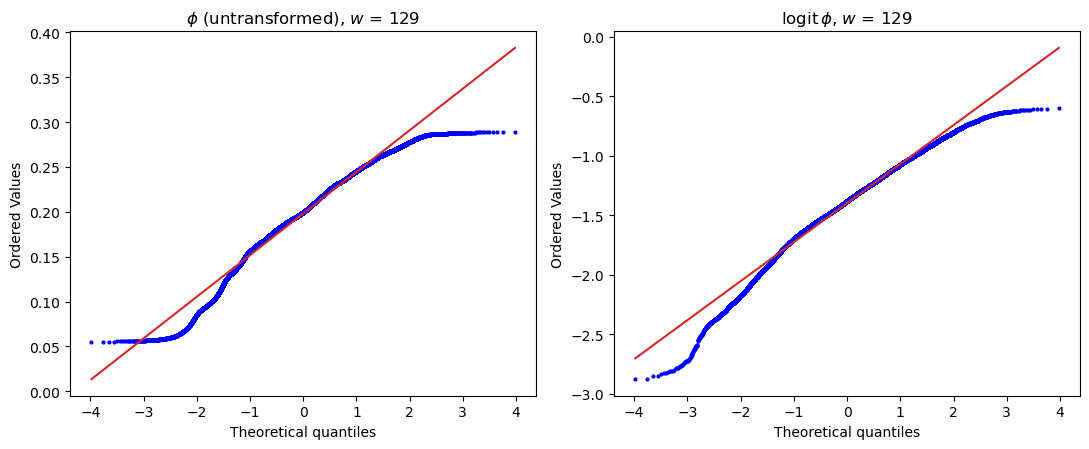

In [9]:
# A quantile-quantile plot is the honest test of normality.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
lg = logit(fields_by_w[fc.WINDOW].ravel())
sub = lg[np.random.choice(lg.size, 20000, replace=False)]

scipy.stats.probplot(fields_by_w[fc.WINDOW].ravel()[:20000], dist='norm', plot=axes[0])
axes[0].set_title(f"$\\phi$ (untransformed), $w$ = {fc.WINDOW}")
scipy.stats.probplot(sub, dist='norm', plot=axes[1])
axes[1].set_title(f"$\\operatorname{{logit}}\\phi$, $w$ = {fc.WINDOW}")
for ax in axes:
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[1].set_color('C3')
fig.tight_layout()
fc.savefig(fig, "01_qq_logit")
plt.show()

Note what the logit buys us and what it does not. It removes the hard boundaries and
straightens the tails; it does not make the field *exactly* Gaussian. The claim in the
thesis is deliberately modest: the field distribution $\mu_\phi$ is assumed to be
*sufficiently characterised by its one- and two-point statistics*. Everything below is a
consequence of that assumption, and it is a modelling choice that could be replaced
(two-point stochastic optimisation, a non-Gaussian random field model) without touching
the rest of the framework.

---
## 5. Fitting at the latent resolution

The conditioning signal is consumed by the diffusion model at **latent** resolution, so
that is where we fit the Gaussian process — average-pool the field by $F=8$ and work on
that grid. Lengths from here on are in *latent units* (1 latent unit = 8 pixels).

We also aggregate over many slices rather than trusting a single one.

valid field (872, 872) -> latent field (109, 109)


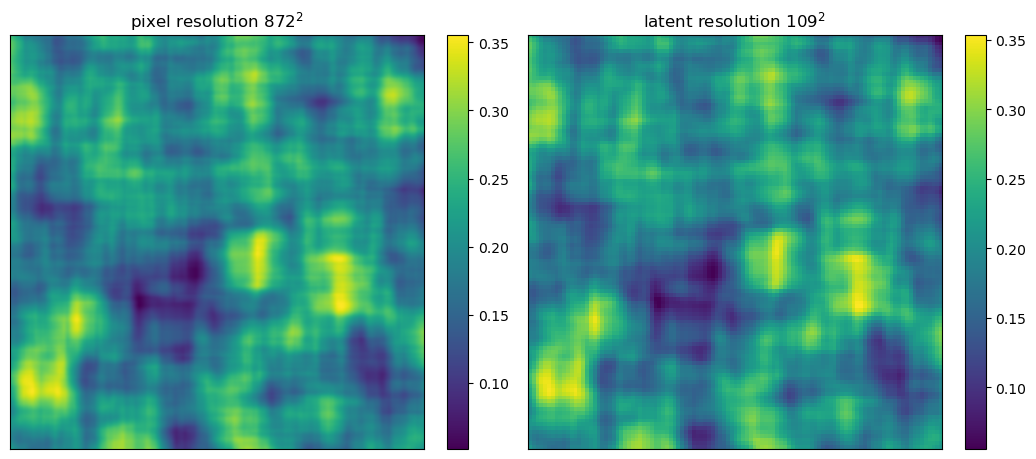

In [10]:
def to_latent(field, factor=fc.F):
    '''Average-pool a field down to latent resolution.'''
    t = torch.from_numpy(np.ascontiguousarray(field, dtype=np.float32))[None, None]
    return F.avg_pool2d(t, kernel_size=factor, stride=factor)[0, 0].numpy()


phi_latent_demo = to_latent(phi_valid)
print(f"valid field {phi_valid.shape} -> latent field {phi_latent_demo.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6))
im = axes[0].imshow(phi_valid, cmap='viridis'); axes[0].set_title(f"pixel resolution {phi_valid.shape[0]}$^2$")
fig.colorbar(im, ax=axes[0], fraction=0.046)
im = axes[1].imshow(phi_latent_demo, cmap='viridis'); axes[1].set_title(f"latent resolution {phi_latent_demo.shape[0]}$^2$")
fig.colorbar(im, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()

### Building the multi-slice stack

We lift `N_SLICES` slices out of the volume and compute the `'same'`-mode field for each.
This is the tutorial's stand-in for the $1000^3$ volume + $1000^3$ field pair that the 3D
pipeline works with. Stored as `float16` to keep the artifact small; the field is smooth
so the precision loss is irrelevant.

In [11]:
FORCE_RECOMPUTE = False

if FORCE_RECOMPUTE or not (os.path.exists(fc.SLICES_PATH) and os.path.exists(fc.FIELD_PATH)):
    t0 = time.time()
    slices = np.ascontiguousarray(volume[:fc.N_SLICES])                       # uint8
    fields = np.empty((fc.N_SLICES, *fc.VOLUME_SHAPE[1:]), dtype=np.float16)
    for i in range(fc.N_SLICES):
        fields[i] = porosity_field_full(slices[i], fc.WINDOW).astype(np.float16)
        if (i + 1) % 40 == 0:
            print(f"  {i + 1}/{fc.N_SLICES} slices  ({time.time() - t0:.0f}s)")
    np.save(fc.SLICES_PATH, slices)
    np.save(fc.FIELD_PATH, fields)
    print(f"saved in {time.time() - t0:.0f}s")
else:
    print("stack already on disk (set FORCE_RECOMPUTE = True to rebuild)")

slices = fc.load_slices()
fields = fc.load_fields()
print(f"slices {slices.shape} {slices.dtype}   fields {fields.shape} {fields.dtype}")
print(f"train slices [0:{fc.TRAIN_SLICES}]   validation slices [{fc.TRAIN_SLICES}:{fc.N_SLICES}]")

stack already on disk (set FORCE_RECOMPUTE = True to rebuild)
slices (160, 1000, 1000) uint8   fields (160, 1000, 1000) float16
train slices [0:120]   validation slices [120:160]


---
## 6. One-point statistics: $m$ and $\theta^2$

The mean and variance of the warped field are read straight off the data — no
optimisation. Crucially they are computed on the **interior** of the field (cropped
inward by $R$), so that no value is contaminated by the boundary normalisation.

In [12]:
R = fc.RADIUS
train_logit = []
for i in range(fc.TRAIN_SLICES):
    interior = np.asarray(fields[i], dtype=np.float32)[R:-R, R:-R]   # drop the boundary belt
    train_logit.append(logit(to_latent(interior)))
train_logit = np.stack(train_logit)

mean_logit = float(train_logit.mean())
var_logit = float(train_logit.var())

print(f"latent field per slice : {train_logit.shape[1:]}")
print(f"m      (mean logit)    : {mean_logit:.4f}   -> phi = {scipy.special.expit(mean_logit):.4f}")
print(f"theta^2 (var logit)    : {var_logit:.4f}   (std = {np.sqrt(var_logit):.4f})")

latent field per slice : (109, 109)
m      (mean logit)    : -1.3431   -> phi = 0.2070
theta^2 (var logit)    : 0.1380   (std = 0.3714)


---
## 7. Two-point statistics: the radial covariance and the Matérn fit

We estimate the radial two-point covariance of the *centred* warped field,

$$\hat{C}(r) \;=\; \operatorname{Cov}\bigl[\sigma(\phi(\mathbf{x})),\, \sigma(\phi(\mathbf{y}))\bigr],\qquad \|\mathbf{x}-\mathbf{y}\| = r,$$

by FFT autocorrelation, then fit a **Matérn 3/2** covariance

$$k(r) \;=\; \theta^2\left(1 + \sqrt{3}\,\frac{r}{\rho}\right)\exp\left(-\sqrt{3}\,\frac{r}{\rho}\right).$$

Two things are *fixed rather than fitted*: the amplitude $\theta^2$ (it is the empirical
variance from the previous cell) and the smoothness $\nu = 3/2$. Only the correlation
length $\rho$ is regressed. $\nu = 3/2$ gives once mean-square-differentiable sample
paths — smooth enough to be a coherent conditioning signal, rough enough to look like
real spatial variability.

The FFT estimator assumes periodicity, which our field is not, so it is only trustworthy
for $r$ well below the field size. We fit over the first quarter of the domain.

In [13]:
# Average the radial covariance over the training slices.
tpc_curves = []
for i in range(fc.TRAIN_SLICES):
    centred = torch.tensor(train_logit[i] - mean_logit, dtype=torch.float32)
    tpc = two_point_correlation.tpcf_fft(centred, bins=50, voxel_size=1.0)
    tpc_curves.append(np.asarray(tpc.correlation))
r_lags = np.asarray(tpc.r)
C_hat = np.mean(np.stack(tpc_curves), axis=0)
C_std = np.std(np.stack(tpc_curves), axis=0)

FIT_RMAX = train_logit.shape[1] / 4.0     # latent units
print(f"radial lags out to r = {r_lags.max():.1f} latent units; fitting over r < {FIT_RMAX:.1f}")
print(f"C_hat(0) = {C_hat[0]:.4f}  vs. empirical variance {var_logit:.4f}")

radial lags out to r = 53.5 latent units; fitting over r < 27.2
C_hat(0) = 0.1344  vs. empirical variance 0.1380


In [14]:
def matern32(r, sigma_sq, length_scale):
    return matern_gaussian_process.matern_covariance_three_half(r, sigma_sq, length_scale)


mask = (r_lags > 1e-10) & (r_lags < FIT_RMAX)
r_fit, C_fit = r_lags[mask], C_hat[mask]

popt, pcov = curve_fit(
    lambda r, ell: matern32(r, var_logit, ell),   # sigma^2 fixed to the empirical variance
    r_fit, C_fit,
    p0=[r_fit[np.abs(C_fit - 0.36 * var_logit).argmin()]],
    bounds=([1e-6], [np.inf]), maxfev=5000,
)
length_scale = float(popt[0])
print(f"fitted correlation length rho = {length_scale:.3f} latent units "
      f"= {length_scale * fc.F:.1f} pixels = {length_scale * fc.F * fc.VOXEL_SIZE_UM:.1f} um")
print(f"                         (window w = {fc.WINDOW} px = {fc.WINDOW / fc.F:.1f} latent units)")

fitted correlation length rho = 7.860 latent units = 62.9 pixels = 141.5 um
                         (window w = 129 px = 16.1 latent units)


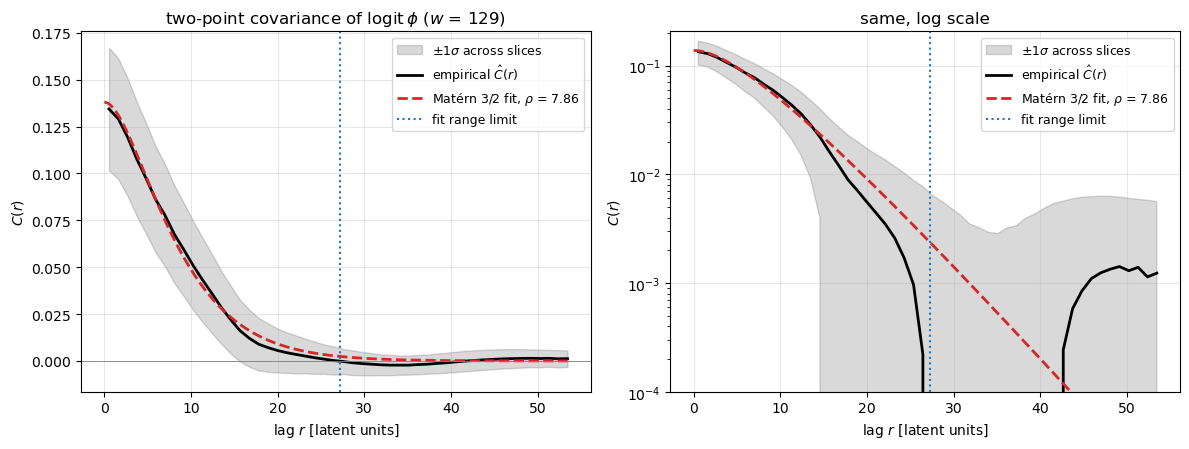

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

for ax, logy in zip(axes, [False, True]):
    ax.fill_between(r_lags, C_hat - C_std, C_hat + C_std, color='k', alpha=0.15,
                    label='$\\pm 1\\sigma$ across slices')
    ax.plot(r_lags, C_hat, 'k-', lw=2, label='empirical $\\hat{C}(r)$')
    rr = np.linspace(1e-3, r_lags.max(), 400)
    ax.plot(rr, matern32(rr, var_logit, length_scale), 'C3--', lw=2,
            label=f'Matérn 3/2 fit, $\\rho$ = {length_scale:.2f}')
    ax.axvline(FIT_RMAX, color='C0', ls=':', lw=1.5, label='fit range limit')
    ax.axhline(0, color='gray', lw=0.6)
    ax.set_xlabel("lag $r$ [latent units]")
    ax.set_ylabel("$C(r)$")
    if logy:
        ax.set_yscale('log'); ax.set_ylim(1e-4, var_logit * 1.5)
        ax.set_title("same, log scale")
    else:
        ax.set_title(f"two-point covariance of $\\operatorname{{logit}}\\phi$ ($w$ = {fc.WINDOW})")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fc.savefig(fig, "01_matern_fit")
plt.show()

---
## 8. Sampling new fields from the fitted process

Three numbers — $m$, $\theta^2$, $\rho$ — now define a complete generative model for the
porosity field. `MaternFieldSampler` builds the covariance matrix on a grid, takes its
Cholesky factor, and draws $y = m + L z$.

The catch: an exact draw on an $N \times N$ grid needs the Cholesky factorisation of an
$N^2 \times N^2$ matrix. At the sizes we generate at (and hopelessly so in 3D) that is
impossible. The pipeline therefore samples **exactly on a coarse $N_c \times N_c$ grid**
and **interpolates** to the target resolution. We will look at what that costs in §9.

In [16]:
sampler = MaternFieldSampler(
    mean_val=mean_logit, sigma_sq=var_logit, nu=1.5, length_scale=length_scale,
)


def sample_field(sampler, shape, coarse_n=fc.COARSE_N, exact=False):
    '''Draw a porosity field of the given latent shape.

    exact=False : sample on a coarse_n^2 grid, then bilinearly interpolate  (pipeline default)
    exact=True  : sample directly on the target grid                        (reference, O(N^6))
    '''
    H, W = shape
    fine_h = np.linspace(0.5, H - 0.5, H)
    fine_w = np.linspace(0.5, W - 0.5, W)
    if exact:
        sampler.initialize_field_from_grid(fine_h, fine_w)
        logit_field = sampler.sample_grid(1)[0]
    else:
        coarse_h = np.linspace(0.5, H - 0.5, coarse_n)
        coarse_w = np.linspace(0.5, W - 0.5, coarse_n)
        sampler.initialize_field_from_grid(coarse_h, coarse_w)
        logit_field = sampler.sample_grid_interpolated(1, fine_h, fine_w)[0]
    return scipy.special.expit(logit_field).astype(np.float32), logit_field


LATENT_SHAPE = (64, 64)     # a 512^2 image at F = 8
phi_gp, logit_gp = sample_field(sampler, LATENT_SHAPE)
print(f"sampled field {phi_gp.shape}: phi in [{phi_gp.min():.3f}, {phi_gp.max():.3f}], mean {phi_gp.mean():.3f}")

sampled field (64, 64): phi in [0.126, 0.486], mean 0.237


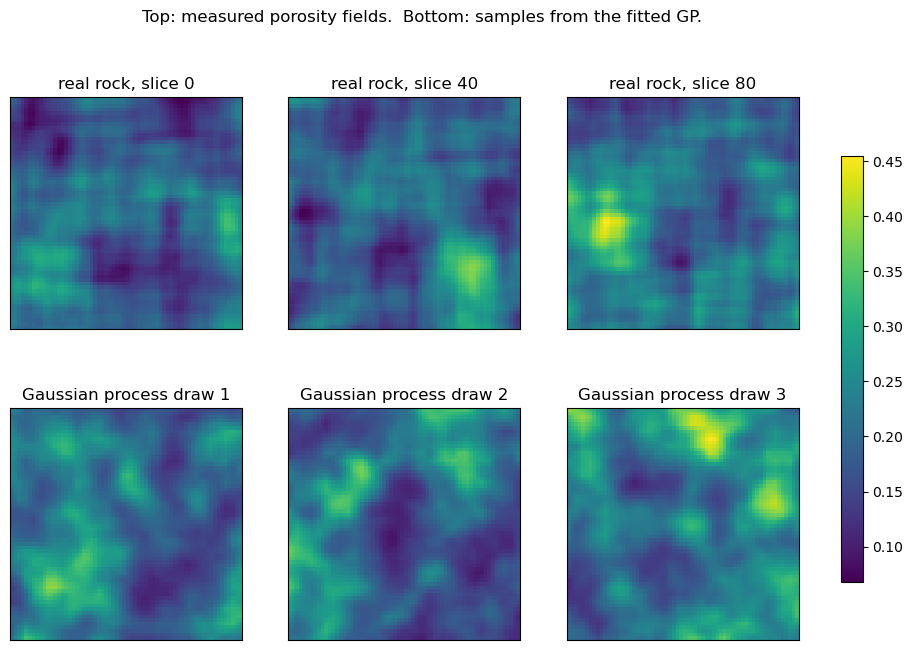

In [17]:
# Real fields (from the rock) vs. GP draws, at the same latent size and colour scale.
real_examples = []
for i in [0, 40, 80]:
    interior = np.asarray(fields[i], dtype=np.float32)[R:-R, R:-R]
    lat = to_latent(interior)
    real_examples.append(lat[:LATENT_SHAPE[0], :LATENT_SHAPE[1]])

gp_examples = [sample_field(sampler, LATENT_SHAPE)[0] for _ in range(3)]

vmin = min(min(a.min() for a in real_examples), min(a.min() for a in gp_examples))
vmax = max(max(a.max() for a in real_examples), max(a.max() for a in gp_examples))

fig, axes = plt.subplots(2, 3, figsize=(11, 7.4))
for k in range(3):
    im = axes[0, k].imshow(real_examples[k], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0, k].set_title(f"real rock, slice {[0, 40, 80][k]}")
    axes[1, k].imshow(gp_examples[k], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1, k].set_title(f"Gaussian process draw {k + 1}")
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, fraction=0.025)
fig.suptitle("Top: measured porosity fields.  Bottom: samples from the fitted GP.", y=0.98)
fc.savefig(fig, "01_gp_vs_real_fields")
plt.show()

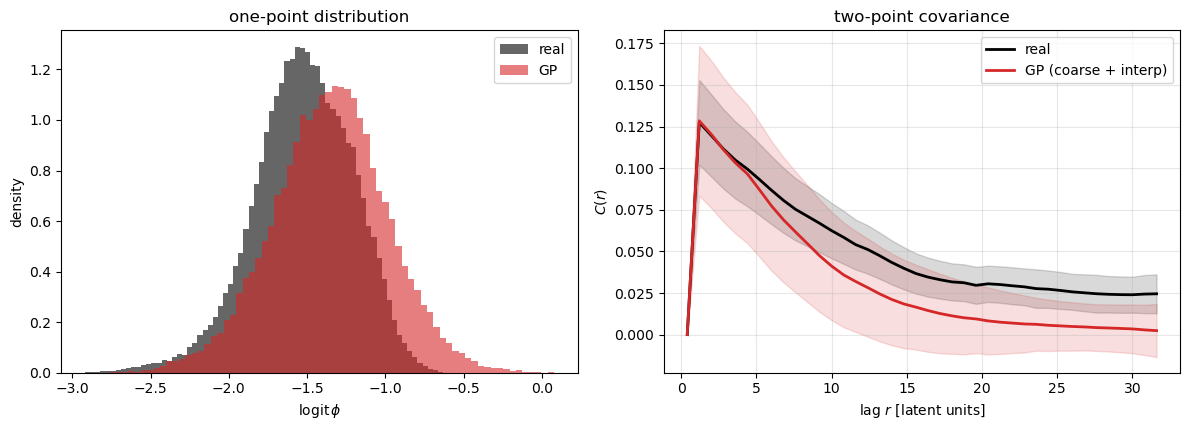

In [18]:
# Do the samples reproduce the one- and two-point statistics they were fitted to?
n_check = 24
gp_logits = np.stack([sample_field(sampler, LATENT_SHAPE)[1] for _ in range(n_check)])
real_logits = np.stack([train_logit[i][:LATENT_SHAPE[0], :LATENT_SHAPE[1]]
                        for i in range(n_check)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

axes[0].hist(real_logits.ravel(), bins=70, density=True, alpha=0.6, label='real', color='k')
axes[0].hist(gp_logits.ravel(), bins=70, density=True, alpha=0.6, label='GP', color='C3')
axes[0].set_xlabel("$\\operatorname{logit}\\phi$"); axes[0].set_ylabel("density")
axes[0].set_title("one-point distribution"); axes[0].legend()

def radial(stack, mean_val):
    curves = [np.asarray(two_point_correlation.tpcf_fft(
        torch.tensor(f - mean_val, dtype=torch.float32), bins=40, voxel_size=1.0).correlation)
        for f in stack]
    rr = np.asarray(two_point_correlation.tpcf_fft(
        torch.tensor(stack[0] - mean_val, dtype=torch.float32), bins=40, voxel_size=1.0).r)
    return rr, np.mean(curves, axis=0), np.std(curves, axis=0)

rr, c_real, s_real = radial(real_logits, mean_logit)
_, c_gp, s_gp = radial(gp_logits, mean_logit)
axes[1].fill_between(rr, c_real - s_real, c_real + s_real, color='k', alpha=0.15)
axes[1].plot(rr, c_real, 'k-', lw=2, label='real')
axes[1].fill_between(rr, c_gp - s_gp, c_gp + s_gp, color='C3', alpha=0.15)
axes[1].plot(rr, c_gp, 'C3-', lw=2, label='GP (coarse + interp)')
axes[1].set_xlabel("lag $r$ [latent units]"); axes[1].set_ylabel("$C(r)$")
axes[1].set_title("two-point covariance"); axes[1].legend(); axes[1].grid(alpha=0.3)

fig.tight_layout()
fc.savefig(fig, "01_gp_statistics_check")
plt.show()

---
## 9. What the coarse-to-fine shortcut costs

Linear interpolation cannot create variability at scales finer than the coarse grid
spacing, so a coarsely-sampled field is **too smooth** and its variance **too low**. The
thesis names this as one of two reasons the generated field variance is under-reproduced
(the other being that the diffusion model only partially follows the field).

How much it costs depends entirely on the **refinement ratio** $N/N_c$ — how much work
interpolation is being asked to do. So rather than assert it, we sweep it.

The sweep has a free reference built in: when $N_c = N$ the interpolant is evaluated at
its own sample points, so it reproduces the **exact** GP draw. Note that even the exact
draw does not hit $\theta^2$ on the nose, because a $64^2$ window spans only a handful of
correlation lengths — that residual gap is finite-sample noise, not approximation error,
and it sets the scale below which differences here mean nothing.

In [ ]:
n_cmp = 16
N = LATENT_SHAPE[0]
coarse_values = [4, 8, 16, 32, N]        # N_c = N is the exact draw

draws = {cn: np.stack([sample_field(sampler, LATENT_SHAPE, coarse_n=cn)[1]
                       for _ in range(n_cmp)])
         for cn in coarse_values}

print(f"target grid {N}^2, target variance theta^2 = {var_logit:.4f}\n")
print(f"{'N_c':>5} {'ratio N/N_c':>12} {'variance':>10} {'% of target':>12}")
for cn in coarse_values:
    v = draws[cn].var()
    tag = '   <- interpolation is exact here' if cn == N else ''
    print(f"{cn:>5} {N / cn:>12.1f} {v:>10.4f} {100 * v / var_logit:>11.0f}%{tag}")

GEN_LATENT, GEN_COARSE = 144, fc.COARSE_N      # what notebook 04 actually uses
print(f"\nNotebook 04 generates a latent {GEN_LATENT}^2 field with N_c = {GEN_COARSE}, "
      f"a refinement ratio of {GEN_LATENT / GEN_COARSE:.1f}.")
print("Read the deficit off the table at that ratio, not at ratio 1 or 2 "
      "(where it is within sampling noise).")

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.4))

vmin, vmax = draws[N][0].min(), draws[N][0].max()
for ax, cn in zip(axes[:2], [N, 8]):
    ax.imshow(draws[cn][0], cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f"$N_c$ = {cn}   (ratio {N // cn})" + ("  — exact" if cn == N else ""))
    ax.set_xticks([]); ax.set_yticks([])

colors = {4: 'C3', 8: 'C1', 16: 'C0', 32: 'C2', N: 'k'}
for cn in coarse_values:
    _, c_cn, _ = radial(draws[cn], mean_logit)
    axes[2].plot(rr, c_cn, color=colors[cn], lw=2, ls='-' if cn == N else '--',
                 label=f"$N_c$ = {cn}" + (" (exact)" if cn == N else ""))
axes[2].plot(rr, c_real, color='0.55', lw=3, alpha=0.8, zorder=0, label='real rock')
axes[2].set_xlabel("lag $r$ [latent units]"); axes[2].set_ylabel("$C(r)$")
axes[2].set_title("coarser grid $\\to$ smoother field")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

ratios = [N / cn for cn in coarse_values]
fracs = [100 * draws[cn].var() / var_logit for cn in coarse_values]
axes[3].plot(ratios, fracs, 'o-', color='C0', lw=2)
axes[3].axhline(100, color='k', ls='--', lw=1, label='target $\\theta^2$')
axes[3].axvline(GEN_LATENT / GEN_COARSE, color='C3', ls=':', lw=2,
                label=f'notebook 04 ({GEN_LATENT / GEN_COARSE:.1f})')
axes[3].set_xscale('log', base=2)
axes[3].set_xlabel("refinement ratio $N / N_c$"); axes[3].set_ylabel("variance [% of $\\theta^2$]")
axes[3].set_title("the deficit, as a function of how\nmuch interpolation must invent")
axes[3].legend(fontsize=9); axes[3].grid(alpha=0.3)

fig.tight_layout()
fc.savefig(fig, "01_coarse_to_fine_cost")
plt.show()

The honest summary, read off the table rather than assumed:

- at ratio 1–2 the shortcut costs **nothing measurable** — the differences there are
  sampling noise, so a comparison run at those ratios proves nothing either way;
- the deficit becomes real from ratio $\approx 4$ onward and grows steeply;
- at the ratio notebook 04 actually generates with ($144/32 \approx 4.5$) roughly a
  **quarter of the field variance is lost** before the diffusion model even sees it.

So the conditioning field we feed the model is genuinely smoother than the real thing, and
we know by how much. Notebook 04 shows the downstream consequence: the generated field
tracks the input field, and therefore inherits its excess smoothness. Fixing this —
circulant embedding to generate the fine-grid residual with the correct spectral content —
is listed as future work in the thesis and would not disturb anything else in the pipeline.

Note the practical corollary: the fix is cheap to approximate by **raising $N_c$**. The
exact-sampling cost is $\mathcal{O}(N_c^6)$ in 2D, so there is a real ceiling, but the
table says where the useful range starts.

---
## 10. Save the fitted parameters

The `.npz` written here plays exactly the role of `*_porosity_analysis.npz` in the 3D
pipeline: it is the handoff from field estimation to generation. Notebooks 04 and 05
load it and never look at the rock again.

In [21]:
np.savez(
    fc.GP_PATH,
    # --- Matern parameters (the generative model for the field) ---
    mean_logit=mean_logit,
    variance_logit=var_logit,
    matern_sigma_sq=var_logit,
    matern_nu=1.5,
    matern_length_scale=length_scale,
    matern_fit_success=True,
    # --- the empirical curve it was fitted to, for later comparison ---
    r=r_lags,
    correlation=C_hat,
    correlation_std=C_std,
    fit_rmax=FIT_RMAX,
    # --- provenance ---
    stone=fc.STONE,
    window=fc.WINDOW,
    radius=fc.RADIUS,
    latent_downsample=fc.F,
    n_slices_used=fc.TRAIN_SLICES,
    voxel_size=1.0,
    method='logit',
)
print(f"saved -> {fc.GP_PATH}")
for k, v in np.load(fc.GP_PATH).items():
    if np.ndim(v) == 0:
        print(f"  {k:24s} {v}")

saved -> /home/ubuntu/repos/DiffSci2/notebooks/tutorials/fieldcontrolling/fcdata/berea_gp_w129_latent.npz
  mean_logit               -1.3431386947631836
  variance_logit           0.13795794546604156
  matern_sigma_sq          0.13795794546604156
  matern_nu                1.5
  matern_length_scale      7.860259843214688
  matern_fit_success       True
  fit_rmax                 27.25
  stone                    Berea
  window                   129
  radius                   64
  latent_downsample        8
  n_slices_used            120
  voxel_size               1.0
  method                   logit


---
## What to carry forward

- A **porosity field** is a local average of the pore indicator: one number per position
  saying how porous the rock is nearby. Window size $w$ is a modelling knob — smaller keeps
  more detail (the thesis's FC-129 beats FC-257 for exactly this reason).
- After a **logit** warp the field is close to Gaussian, so three numbers
  $(m, \theta^2, \rho)$ define a usable generative model $\mu_\phi$ for it.
- We fit at **latent resolution**, because that is where the diffusion model consumes it.
- The coarse-grid-plus-interpolation sampler is an approximation that **under-produces
  fine-scale variance**. Know this when reading notebook 04's results.

**Artifacts written:** `berea_slices.npy`, `berea_field_w129.npy`, `berea_gp_w129_latent.npz`.

**Next:** `02-scalar-porosity-pretraining.ipynb` — train the diffusion model to obey a
*single number*, before teaching it to obey a whole field.